In [1]:
# ============================================
# LIBRERÍAS REQUERIDAS
# ============================================
import pandas as pd
import matplotlib.pyplot as plt
import glob
import random

In [2]:
# ============================================
# 1. CARGAR Y SELECCIONAR MUESTRA DE DATOS
# ============================================
# Establecer seed para reproducibilidad
random.seed(1)

# Buscar archivos CSV de eventos
nov_files = glob.glob("./data/online+retail/split/2019-Nov_part_*.csv")
oct_files = glob.glob("./data/online+retail/split/2019-Oct_part_*.csv")

# Seleccionar 10 archivos aleatorios de cada mes
nov_sample = random.sample(nov_files, 10)
oct_sample = random.sample(oct_files, 10)

print("\n=== DATOS CARGADOS ===\n")
print(f"Archivos seleccionados (Noviembre): {len(nov_sample)}")
print(f"Archivos seleccionados (Octubre): {len(oct_sample)}")


=== DATOS CARGADOS ===

Archivos seleccionados (Noviembre): 10
Archivos seleccionados (Octubre): 10


In [3]:
# ============================================
# 2. CONSOLIDAR DATOS
# ============================================
# Combinar archivos en un único dataframe
files = nov_sample + oct_sample

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print(f"Tamaño dataset consolidado: {data.shape[0]:,} registros x {data.shape[1]} columnas")

Tamaño dataset consolidado: 20,000,000 registros x 9 columnas


In [4]:
# ============================================
# 3. PREPARACIÓN Y VARIABLES TEMPORALES
# ============================================
# Convertir timestamp a datetime
data["event_time"] = pd.to_datetime(data["event_time"])

# Crear variables útiles para análisis temporal
data["hour"] = data["event_time"].dt.hour  # hora del evento
data["date"] = data["event_time"].dt.date  # fecha del evento

In [5]:
# ============================================
# 4. EXPLORACIÓN INICIAL DE LOS DATOS
# ============================================
print("\n=== PRIMERAS FILAS DEL DATASET ===\n")
print(data.head())


=== PRIMERAS FILAS DEL DATASET ===

                 event_time event_type  product_id          category_id  \
0 2019-11-14 08:39:08+00:00       view     1005232  2053013555631882655   
1 2019-11-14 08:39:08+00:00       cart     3600666  2053013563810775923   
2 2019-11-14 08:39:09+00:00       view     1005160  2053013555631882655   
3 2019-11-14 08:39:09+00:00       view     1005239  2053013555631882655   
4 2019-11-14 08:39:09+00:00       view    26500318  2053013563550729061   

               category_code    brand   price    user_id  \
0     electronics.smartphone   xiaomi  118.15  530056071   
1  appliances.kitchen.washer  samsung  321.73  517658709   
2     electronics.smartphone   xiaomi  203.03  556643578   
3     electronics.smartphone   xiaomi  268.96  512886445   
4                        NaN  lucente   25.48  541888295   

                           user_session  hour        date  
0  8a868f47-c065-4600-829d-fcee14fbb365     8  2019-11-14  
1  ec3cc5c8-3572-4f79-ada8-63ac

In [6]:
# Información de estructura y tipos de datos
print("\n=== ESTRUCTURA DEL DATASET ===\n")
print(data.info())


=== ESTRUCTURA DEL DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000000 entries, 0 to 19999999
Data columns (total 11 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[ns, UTC]
 1   event_type     object             
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  object             
 5   brand          object             
 6   price          float64            
 7   user_id        int64              
 8   user_session   object             
 9   hour           int32              
 10  date           object             
dtypes: datetime64[ns, UTC](1), float64(1), int32(1), int64(3), object(5)
memory usage: 1.6+ GB
None


In [7]:
# Análisis de valores nulos
print("\n=== PROPORCIÓN DE VALORES NULOS ===\n")
print(data.isnull().sum() / data.shape[0])


=== PROPORCIÓN DE VALORES NULOS ===

event_time       0.000000e+00
event_type       0.000000e+00
product_id       0.000000e+00
category_id      0.000000e+00
category_code    3.172597e-01
brand            1.445045e-01
price            0.000000e+00
user_id          0.000000e+00
user_session     5.000000e-08
hour             0.000000e+00
date             0.000000e+00
dtype: float64


In [8]:
# Estadísticas descriptivas numéricas
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===\n")
print(data.describe())


=== ESTADÍSTICAS DESCRIPTIVAS ===

         product_id   category_id         price       user_id          hour
count  2.000000e+07  2.000000e+07  2.000000e+07  2.000000e+07  2.000000e+07
mean   1.172955e+07  2.057702e+18  2.931069e+02  5.362526e+08  1.192329e+01
std    1.523765e+07  1.942078e+16  3.567542e+02  2.107486e+07  4.938234e+00
min    1.000978e+06  2.053014e+18  0.000000e+00  4.948454e+07  0.000000e+00
25%    1.005253e+06  2.053014e+18  6.937000e+01  5.162460e+08  8.000000e+00
50%    5.100337e+06  2.053014e+18  1.670600e+02  5.322198e+08  1.300000e+01
75%    1.720082e+07  2.053014e+18  3.603400e+02  5.554910e+08  1.600000e+01
max    1.000285e+08  2.187708e+18  2.574070e+03  5.797422e+08  2.300000e+01


In [9]:
# ============================================
# 5. ANÁLISIS DE TIPOS DE EVENTOS
# ============================================
# Distribución de frecuencias de eventos
event_counts = data["event_type"].value_counts()

print("\n=== DISTRIBUCIÓN DE TIPOS DE EVENTO ===\n")
print(event_counts)
print(f"\n=== PROPORCIÓN (%) ===\n")
print((data["event_type"].value_counts(normalize=True) * 100).round(2))


=== DISTRIBUCIÓN DE TIPOS DE EVENTO ===

event_type
view        19017857
cart          703545
purchase      278598
Name: count, dtype: int64

=== PROPORCIÓN (%) ===

event_type
view        95.09
cart         3.52
purchase     1.39
Name: proportion, dtype: float64


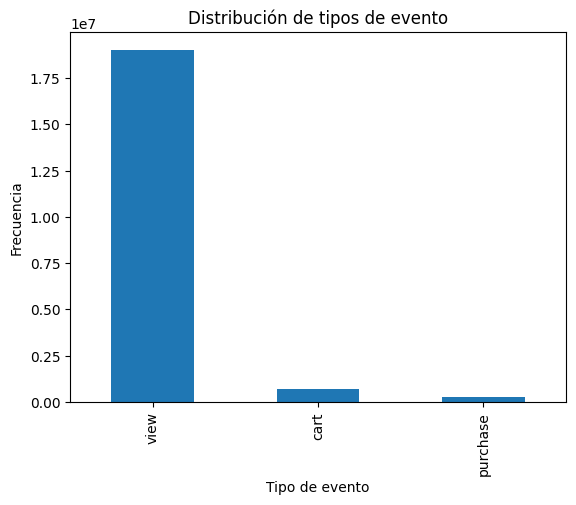

In [10]:
# Visualización: Distribución de tipos de evento
plt.figure()
event_counts.plot(kind="bar")
plt.title("Distribución de tipos de evento")
plt.xlabel("Tipo de evento")
plt.ylabel("Frecuencia")
plt.show()

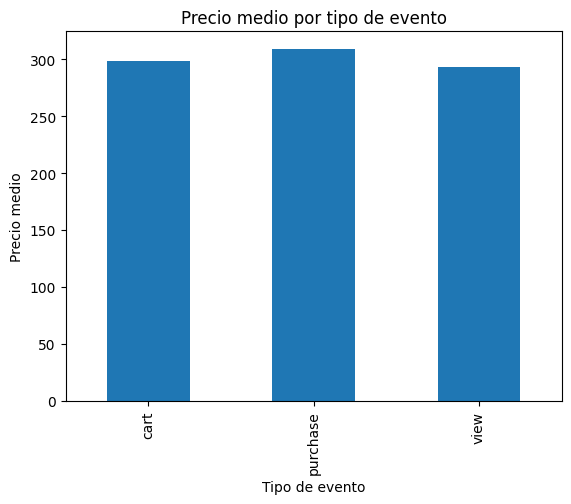

In [11]:
# Análisis de precios por tipo de evento
price_event = data.groupby("event_type")["price"].mean()

# Visualización: Precio promedio por tipo de evento
plt.figure()
price_event.plot(kind="bar")
plt.title("Precio medio por tipo de evento")
plt.xlabel("Tipo de evento")
plt.ylabel("Precio medio")
plt.show()

In [12]:
# ============================================
# 6. ANÁLISIS DE EVENTOS POR USUARIO
# ============================================
# Contar eventos por usuario
events_user = data.groupby("user_id").size()
distribution = events_user.value_counts().sort_index()

print("\n=== DISTRIBUCIÓN DE EVENTOS POR USUARIO (Primeras 20) ===\n")
print(distribution.head(20))


=== DISTRIBUCIÓN DE EVENTOS POR USUARIO (Primeras 20) ===

1     451167
2     244925
3     177636
4     134691
5     103752
6      84406
7      71042
8      60210
9      51809
10     45468
11     39585
12     35214
13     31080
14     28280
15     25279
16     23008
17     20668
18     19083
19     17414
20     15828
Name: count, dtype: int64


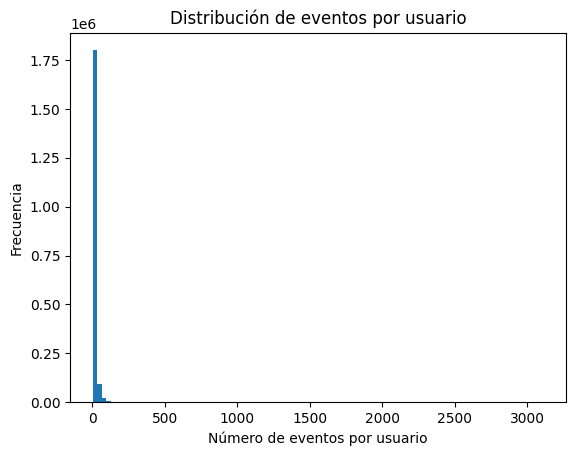

In [13]:
# Visualización: Histograma de eventos por usuario
plt.figure()
plt.hist(events_user, bins=100)
plt.title("Distribución de eventos por usuario")
plt.xlabel("Número de eventos por usuario")
plt.ylabel("Frecuencia")
plt.show()

In [14]:
# ============================================
# 7. ANÁLISIS DE MARCAS
# ============================================
# Top 10 marcas por frecuencia
print("\n=== TOP 10 MARCAS ===\n")
print(data["brand"].value_counts().head(10))


=== TOP 10 MARCAS ===

brand
samsung    2406620
apple      1864265
xiaomi     1394835
huawei      463812
lucente     342806
lg          308471
bosch       280665
oppo        243406
sony        224795
acer        209127
Name: count, dtype: int64


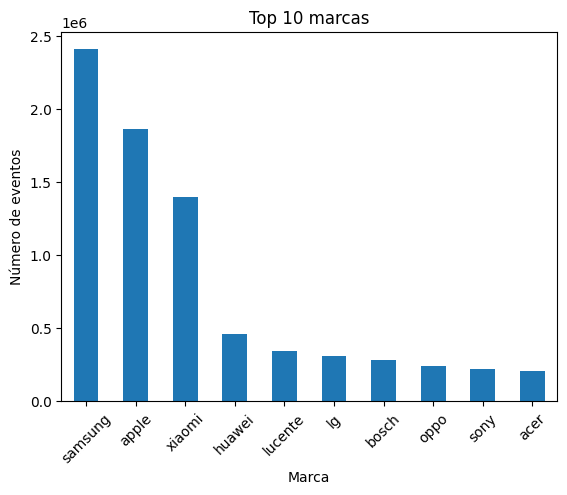

In [15]:
# Visualización: Top 10 marcas
top_brands = data["brand"].value_counts().head(10)

plt.figure()
top_brands.plot(kind="bar")
plt.title("Top 10 marcas")
plt.xlabel("Marca")
plt.ylabel("Número de eventos")
plt.xticks(rotation=45)
plt.show()

In [16]:
# ============================================
# 8. ANÁLISIS DE CATEGORÍAS
# ============================================
# Top 10 categorías
top_categories = data["category_code"].value_counts().head(10)

print("\n=== TOP 10 CATEGORÍAS ===\n")
print(top_categories)


=== TOP 10 CATEGORÍAS ===

category_code
electronics.smartphone              5073805
electronics.clocks                   628444
electronics.video.tv                 622604
computers.notebook                   607566
electronics.audio.headphone          518270
apparel.shoes                        494297
appliances.kitchen.refrigerators     428307
appliances.environment.vacuum        419427
appliances.kitchen.washer            416831
computers.desktop                    206272
Name: count, dtype: int64


In [17]:
# Análisis de categorías en compras
purchases = data[data["event_type"] == "purchase"]

print("\n=== TOP 10 CATEGORÍAS EN COMPRAS ===\n")
print(purchases["category_code"].value_counts().head(10))


=== TOP 10 CATEGORÍAS EN COMPRAS ===

category_code
electronics.smartphone              124841
electronics.audio.headphone          12436
electronics.video.tv                  8697
electronics.clocks                    7051
appliances.kitchen.washer             5964
computers.notebook                    5837
appliances.environment.vacuum         4911
appliances.kitchen.refrigerators      3938
apparel.shoes                         2352
electronics.tablet                    2122
Name: count, dtype: int64


In [18]:
# ============================================
# 9. ANÁLISIS DE PRECIOS
# ============================================
print("\n=== ESTADÍSTICAS DE PRECIOS ===\n")
print(f"Precio promedio: {data['price'].mean():.2f}")
print(f"Precio máximo: {data['price'].max():.2f}")
print(f"Precio mínimo: {data['price'].min():.2f}")


=== ESTADÍSTICAS DE PRECIOS ===

Precio promedio: 293.11
Precio máximo: 2574.07
Precio mínimo: 0.00


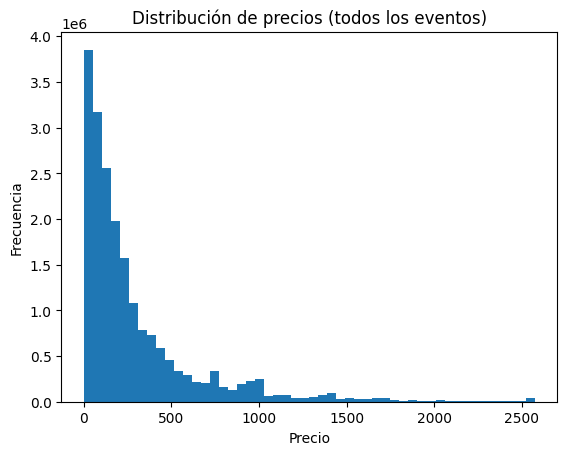

In [19]:
# Visualización: Distribución de precios
plt.figure()
plt.hist(data["price"].dropna(), bins=50)
plt.title("Distribución de precios (todos los eventos)")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

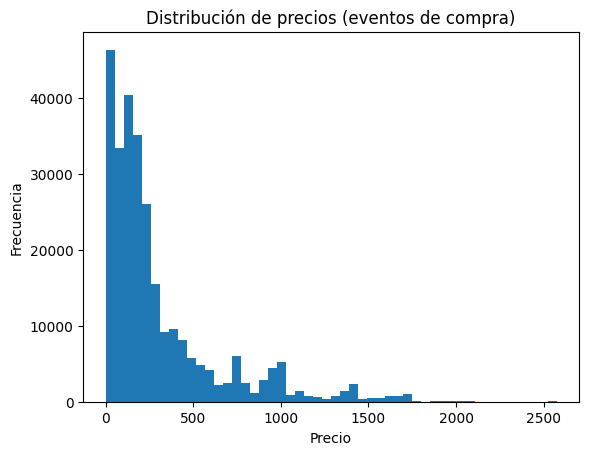

In [20]:
# Visualización: Distribución de precios en compras
purchase_prices = purchases["price"]

plt.figure()
plt.hist(purchase_prices.dropna(), bins=50)
plt.title("Distribución de precios (eventos de compra)")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

In [21]:
# ============================================
# 10. ANÁLISIS DE COBERTURA DE USUARIOS Y SESIONES
# ============================================
print("\n=== COBERTURA DE USUARIOS Y SESIONES ===\n")
print(f"Usuarios únicos: {data['user_id'].nunique():,}")
print(f"Sesiones únicas: {data['user_session'].nunique():,}")


=== COBERTURA DE USUARIOS Y SESIONES ===

Usuarios únicos: 1,932,110
Sesiones únicas: 4,165,281


In [22]:
# Información adicional de sesiones
print(f"Promedio de eventos por sesión: {len(data) / data['user_session'].nunique():.2f}")

Promedio de eventos por sesión: 4.80


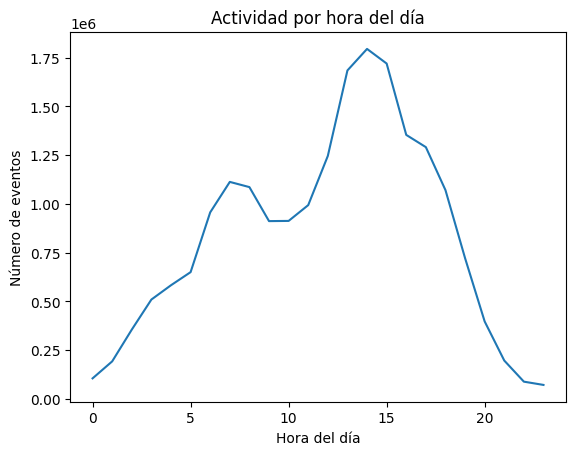

In [23]:
# ============================================
# 11. ANÁLISIS TEMPORAL - ACTIVIDAD POR HORA
# ============================================
# Contar eventos por hora del día
data["hour"] = data["event_time"].dt.hour
events_hour = data.groupby("hour").size()

# Visualización: Actividad por hora
plt.figure()
events_hour.plot()
plt.title("Actividad por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Número de eventos")
plt.show()

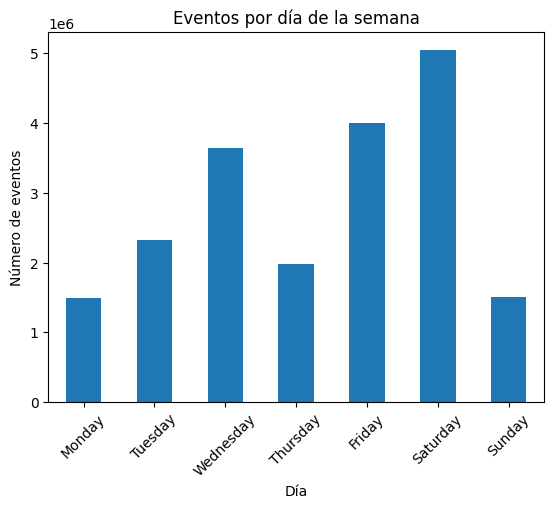

In [24]:
# ============================================
# 12. ANÁLISIS TEMPORAL - ACTIVIDAD POR DÍA DE LA SEMANA
# ============================================
# Agrupar por día de la semana
data["weekday"] = data["event_time"].dt.day_name()

weekday_events = data.groupby("weekday").size()
weekday_events = weekday_events.reindex([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])

# Visualización: Eventos por día de la semana
plt.figure()
weekday_events.plot(kind="bar")
plt.title("Eventos por día de la semana")
plt.xlabel("Día")
plt.ylabel("Número de eventos")
plt.xticks(rotation=45)
plt.show()